In [30]:
import pandas as pd
df = pd.read_csv('customer_shopping_behavior.csv')

In [31]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [33]:
df.describe()  ##describe only gives summary statistics for numerical data

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [34]:
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [35]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [36]:
## we can replace the null values with median and not mean because mean can get affected by outliers and median is robust to outliers
## here we have group by the category so that median will fill according to each categories median and not just overall median
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [37]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [38]:
## we will make every column's name lowercase and replace spaces with underscore cause it easier to reference your code in sql and python
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [39]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

### Feature engineering

In [40]:
## create a column age group
labels = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']
df['age_group'] = pd.qcut(df['age'],q=4, labels=labels)

In [41]:
df[['age','age_group']]

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
...,...,...
3895,40,Adult
3896,52,Middle-aged
3897,46,Middle-aged
3898,44,Adult


In [42]:
frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,        
    'Bi-Weekly': 14,
    'Annually': 365,        
    'Every 3 Months': 90    
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [43]:
df['purchase_frequency_days'].isnull().sum()

np.int64(0)

In [44]:
df['purchase_frequency_days']

0        14
1        14
2         7
3         7
4       365
       ... 
3895      7
3896     14
3897     90
3898      7
3899     90
Name: purchase_frequency_days, Length: 3900, dtype: int64

In [45]:
df[['discount_applied','promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [46]:
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

In [47]:
## since both columns are same values so we don't need both of the columns
df = df.drop('promo_code_used',axis=1)

In [48]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

### Customer Segmentation via k-means

In [49]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

features = ['purchase_amount', 'previous_purchases', 'purchase_frequency_days']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [50]:
## Elbow method + silhouette score to choose k
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(X_scaled)
    print(f"k={k}: inertia={km.inertia_:.1f}, silhouette={silhouette_score(X_scaled, cluster_labels):.3f}")

d:\annaconda\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\annaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "d:\annaconda\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "d:\annaconda\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        

k=2: inertia=8096.8, silhouette=0.443
k=3: inertia=5586.6, silhouette=0.348
k=4: inertia=4048.0, silhouette=0.358
k=5: inertia=3079.3, silhouette=0.374
k=6: inertia=2635.0, silhouette=0.372
k=7: inertia=2366.5, silhouette=0.349


In [51]:
## Fit final model with chosen k
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_scaled)

## Profile each cluster
profile = df.groupby('cluster')[features].mean().round(1)
profile['count'] = df['cluster'].value_counts().sort_index()
profile['revenue_share_%'] = (df.groupby('cluster')['purchase_amount'].sum() / df['purchase_amount'].sum() * 100).round(1)
profile

,purchase_amount,previous_purchases,purchase_frequency_days,count,revenue_share_%
cluster,,,,,
0,36.2,31.3,40.5,1133,17.6
1,79.9,36.8,42.8,1010,34.6
2,60.2,24.6,365.0,572,14.8
3,64.9,10.2,42.0,1185,33.0


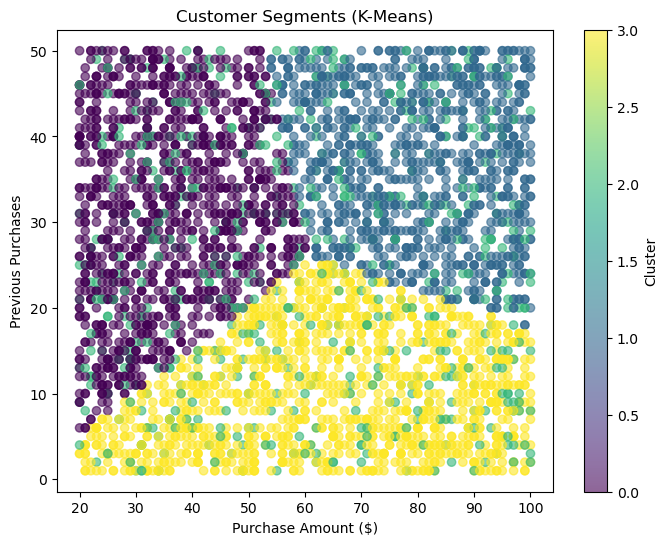

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
scatter = plt.scatter(df['purchase_amount'], df['previous_purchases'], c=df['cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('Purchase Amount ($)')
plt.ylabel('Previous Purchases')
plt.title('Customer Segments (K-Means)')
plt.colorbar(scatter, label='Cluster')
plt.show()

**Key insight:** Clusters 0 and 1 have nearly identical purchase frequency (31.3 vs. 36.8 previous purchases), but Cluster 1 spends more than **double** per customer. A single-variable loyalty rule (based on purchase count alone, as used earlier) would incorrectly group these two behaviorally distinct segments together — masking the fact that high purchase frequency does not necessarily mean high value.

**Business implications:**
- **High-Value Loyalists (Cluster 1)** — smallest-to-mid sized group but disproportionate revenue contribution; strongest candidates for retention/loyalty investment.
- **Frequent Low-Spenders (Cluster 0)** — high engagement but low basket size; a target for upsell/cross-sell campaigns rather than pure retention.
- **Growing/Occasional Spenders (Cluster 3)** — newer customers (low previous-purchase count) already spending well; a segment to nurture toward Cluster 1 behavior.
- **Annual/Rare Buyers (Cluster 2)** — infrequent by nature (~once/year); reactivation campaigns timed around their purchase cycle may be more effective than frequency-based promotions.

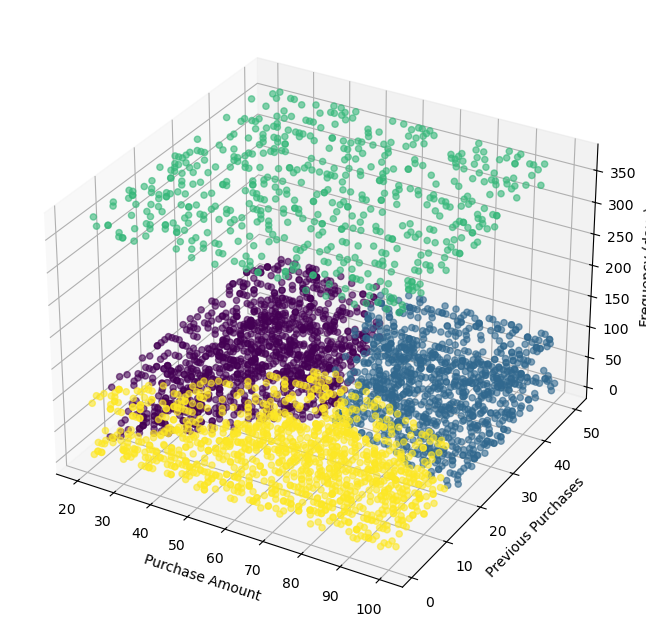

In [53]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['purchase_amount'], df['previous_purchases'], df['purchase_frequency_days'], c=df['cluster'], cmap='viridis', alpha=0.6)
ax.set_xlabel('Purchase Amount')
ax.set_ylabel('Previous Purchases')
ax.set_zlabel('Frequency (days)')
plt.show()

In [19]:
pip install psycopg2-binary sqlalchemy

^C
Note: you may need to restart the kernel to use updated packages.


   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   -------------------------------

In [20]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

username = "postgres"
password = quote_plus("Rohitpatel@12345")  # URL-encode the password
host = "localhost"
port = "5432"
database = "customer_behavior"

# Create engine safely
engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Load dataframe into PostgreSQL (not MySQL)
table_name = 'customer'
df.to_sql(name=table_name, con=engine, if_exists='replace', index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'")


Data successfully loaded into table 'customer' in database 'customer_behavior'
